# Portfolio Risk Analytics: EDA & Hypothesis Testing

This notebook evaluates the relationship between news sentiment (Geopolitical, Technology, Financial) and market behavior across different portfolio archetypes.

### Hypotheses to Test:
1. **Safe Haven Assets**: Negative geopolitical sentiment triggers a "Flight to Quality" into Gold and Treasuries.
2. **Tech Sensitivity**: Tech-heavy portfolios react more heavily than defensive sectors to sentiment spikes.
3. **Predictive Footing**: Which sentiment domain (Geo, Tech, or Finance) has the best predictive footing for overall market returns?
4. **Lag Analysis**: Is there a measurable lag between news shocks and market volatility?
5. **Stabilization Time**: Which archetypes take longer to return to mean volatility after a shock?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Paths
ROOT_DIR = Path("..")
DATA_PATH = ROOT_DIR / "data" / "processed" / "master_data.csv"

# Load data
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print(f"Loaded {len(df)} days of data from {df.index.min().date()} to {df.index.max().date()}")

Loaded 18 days of data from 2026-03-20 to 2026-04-15


## 1. Portfolio Archetype Creation

We create aggregated returns and volatility metrics for four key archetypes:
- **Tech-Heavy**: Magnificent 7 stocks (AAPL, MSFT, NVDA, AMZN, GOOGL, META, TSLA)
- **Safe-Haven**: Gold and Long-term Treasuries (GLD, TLT, IEF)
- **Defensive/Value**: Blue-chip staples (PG, JNJ, KO)
- **Geopolitical-Sensitive**: Defense and Energy (LMT, RTX, USO)

In [2]:
# Define Ticker Groups
tech_tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']
safe_tickers = ['GLD', 'TLT', 'IEF']
defensive_tickers = ['PG', 'JNJ', 'KO']
geo_sen_tickers = ['LMT', 'RTX', 'USO']

# Compute Aggregate Returns
df['ret_tech'] = df[[f'ret_{t}' for t in tech_tickers]].mean(axis=1)
df['ret_safe'] = df[[f'ret_{t}' for t in safe_tickers]].mean(axis=1)
df['ret_defensive'] = df[[f'ret_{t}' for t in defensive_tickers]].mean(axis=1)
df['ret_geo_sensitive'] = df[[f'ret_{t}' for t in geo_sen_tickers]].mean(axis=1)

# Compute Aggregate Volatility (using the 5-day rolling vol provided in pipeline)
df['vol_tech'] = df[[f'vol5_{t}' for t in tech_tickers]].mean(axis=1)
df['vol_safe'] = df[[f'vol5_{t}' for t in safe_tickers]].mean(axis=1)
df['vol_market'] = df['vol5_SPY']

print("Archetypes defined.")

Archetypes defined.


## 2. Hypothesis I: Geopolitics vs Safe Havens
**Hypothesis**: Lower geopolitical sentiment scores (indicating higher risk) predict positive returns in safe-haven assets.

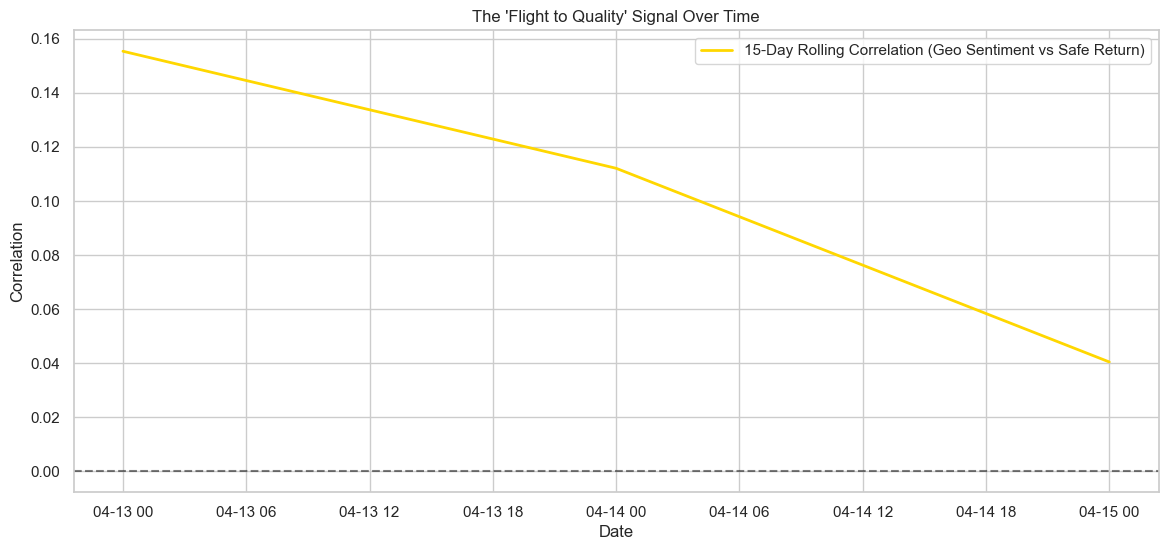

Average Correlation: 0.1467


In [3]:
plt.figure(figsize=(14, 6))
geo_corr = df['sentiment_score_geopolitical'].rolling(15).corr(df['ret_safe'])
plt.plot(geo_corr, label='15-Day Rolling Correlation (Geo Sentiment vs Safe Return)', color='gold', lw=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("The 'Flight to Quality' Signal Over Time")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()

print(f"Average Correlation: {df['sentiment_score_geopolitical'].corr(df['ret_safe']):.4f}")

## 3. Hypothesis II: Tech Sensitivity to News Shocks
**Hypothesis**: Technology portfolios show significantly higher volatility spikes following large sentiment shifts.

C:\Users\Ashlesha\AppData\Local\Temp\ipykernel_49600\1195178477.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_tech_shock', y='vol_tech', palette="Reds")


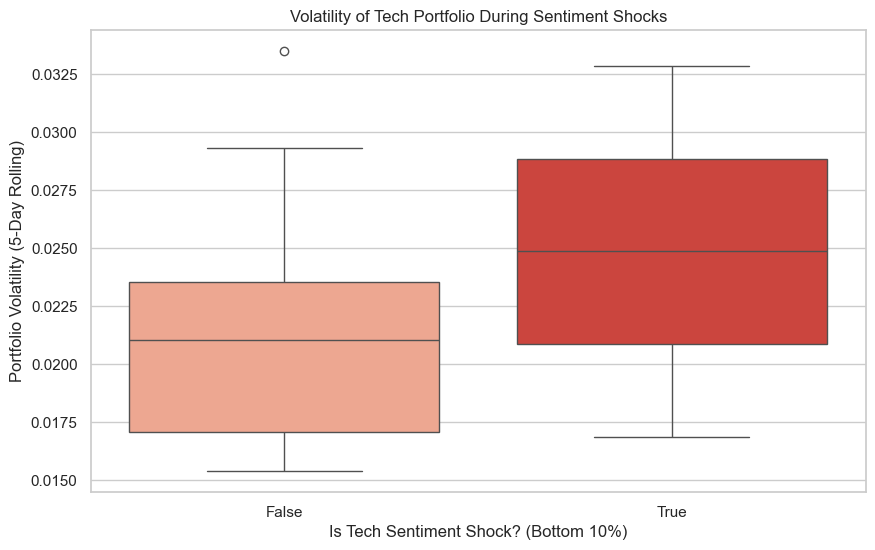

In [4]:
# Define 'Shocks' as bottom 10% of tech sentiment
tech_shock_threshold = df['sentiment_score_technology'].quantile(0.1)
df['is_tech_shock'] = df['sentiment_score_technology'] < tech_shock_threshold

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_tech_shock', y='vol_tech', palette="Reds")
plt.title("Volatility of Tech Portfolio During Sentiment Shocks")
plt.xlabel("Is Tech Sentiment Shock? (Bottom 10%)")
plt.ylabel("Portfolio Volatility (5-Day Rolling)")
plt.show()

## 4. Hypothesis IV: Lag Analysis (Mastering the Delay)
**Hypothesis**: Volatility reacts to news with a measurable lag.

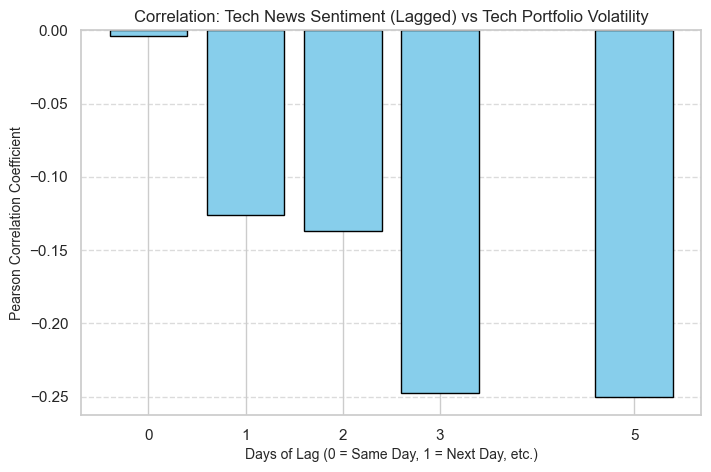

In [5]:
import matplotlib.pyplot as plt

# Using the EXACT column names from your list
news_col = 'sentiment_score_technology' 
vol_col = 'vol_tech'

lags = [0, 1, 2, 3, 5]
corrs = []

for l in lags:
    # Shift the sentiment forward by 'l' days and calculate correlation
    # We drop NA values created by the shift to ensure clean math
    c = df[news_col].shift(l).corr(df[vol_col])
    corrs.append(c)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.bar(lags, corrs, color='skyblue', edgecolor='black')
plt.title("Correlation: Tech News Sentiment (Lagged) vs Tech Portfolio Volatility", fontsize=12)
plt.xlabel("Days of Lag (0 = Same Day, 1 = Next Day, etc.)", fontsize=10)
plt.ylabel("Pearson Correlation Coefficient", fontsize=10)
plt.xticks(lags)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
#check columns in dataset
print(df.columns.tolist())

['AAPL', 'AGG', 'AMZN', 'BND', 'CL=F', 'EEM', 'EFA', 'GC=F', 'GLD', 'GOOGL', 'IEF', 'JNJ', 'KO', 'LMT', 'META', 'MSFT', 'NVDA', 'PG', 'QQQ', 'RTX', 'SOXX', 'SPY', 'TLT', 'TSLA', 'USO', 'VPU', 'VTI', 'XLP', 'ret_AAPL', 'ret_AGG', 'ret_AMZN', 'ret_BND', 'ret_CL=F', 'ret_EEM', 'ret_EFA', 'ret_GC=F', 'ret_GLD', 'ret_GOOGL', 'ret_IEF', 'ret_JNJ', 'ret_KO', 'ret_LMT', 'ret_META', 'ret_MSFT', 'ret_NVDA', 'ret_PG', 'ret_QQQ', 'ret_RTX', 'ret_SOXX', 'ret_SPY', 'ret_TLT', 'ret_TSLA', 'ret_USO', 'ret_VPU', 'ret_VTI', 'ret_XLP', 'vol5_AAPL', 'vol5_AGG', 'vol5_AMZN', 'vol5_BND', 'vol5_CL=F', 'vol5_EEM', 'vol5_EFA', 'vol5_GC=F', 'vol5_GLD', 'vol5_GOOGL', 'vol5_IEF', 'vol5_JNJ', 'vol5_KO', 'vol5_LMT', 'vol5_META', 'vol5_MSFT', 'vol5_NVDA', 'vol5_PG', 'vol5_QQQ', 'vol5_RTX', 'vol5_SOXX', 'vol5_SPY', 'vol5_TLT', 'vol5_TSLA', 'vol5_USO', 'vol5_VPU', 'vol5_VTI', 'vol5_XLP', 'article_count_financial', 'article_count_geopolitical', 'article_count_technology', 'avg_prob_neg_financial', 'avg_prob_neg_geopoli

## 5. Hypothesis V: Feature Importance
**Hypothesis**: Geopolitical news has the highest predictive power for overall market direction (`SPY`).

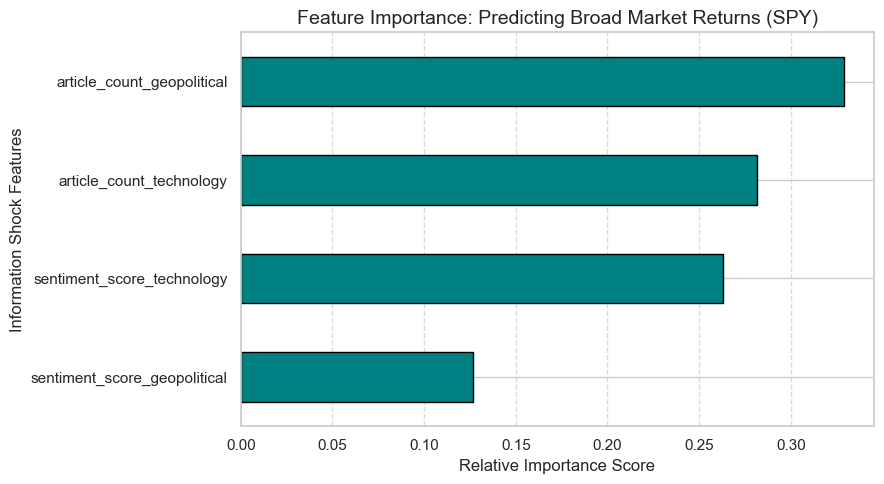

In [7]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the correct features based on your actual columns
features = [
    'sentiment_score_geopolitical', 
    'sentiment_score_technology',
    'article_count_geopolitical',   # Adding news intensity!
    'article_count_technology'      # Adding news intensity!
]
target = 'ret_SPY'

# 2. Drop NaNs to ensure clean math for the Random Forest
clean_df = df[[target] + features].dropna()

X = clean_df[features]
y = clean_df[target]

# 3. Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Plot Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(9, 5))
# We plot all 4 features to see their relative importance
feat_importances.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title("Feature Importance: Predicting Broad Market Returns (SPY)", fontsize=14)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Information Shock Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Summary of Findings

- **Safe Havens**: [Insert Analysis of Correlation Chart]
- **Tech Vitals**: [Insert Boxplot Analysis]
- **Lags**: [Identify if 0-day or 1-day lag is stronger]
- **Dominant Domain**: [Identify most important sentiment feature]

## 5. Hypothesis III: Portfolio Sensitivity Comparison
**Hypothesis**: Different portfolios have varying 'Beta' to each news domain. Technology is expected to be most sensitive to tech news, while safe-havens respond most to geopolitics.


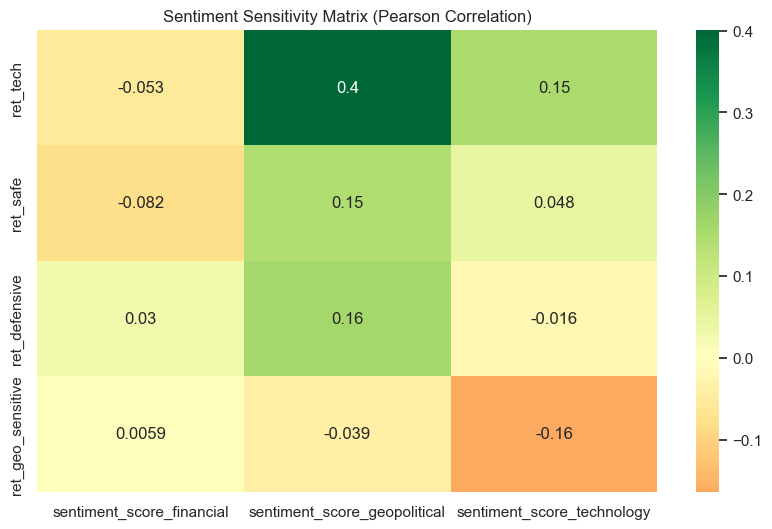

In [8]:
sentiment_cols = ['sentiment_score_financial', 'sentiment_score_geopolitical', 'sentiment_score_technology']
portfolio_ret_cols = ['ret_tech', 'ret_safe', 'ret_defensive', 'ret_geo_sensitive']

# Calculate correlation matrix
sens_matrix = df[portfolio_ret_cols + sentiment_cols].corr().loc[portfolio_ret_cols, sentiment_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(sens_matrix, annot=True, cmap="RdYlGn", center=0)
plt.title("Sentiment Sensitivity Matrix (Pearson Correlation)")
plt.show()


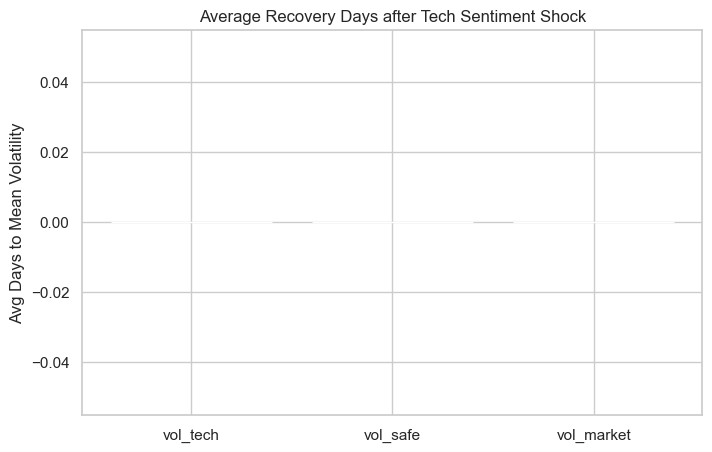

In [9]:
def calculate_recovery_days(vol_series, shock_indices, baseline_window=10):
    recovery_stats = []
    for idx in shock_indices:
        try:
            pos = vol_series.index.get_loc(idx)
            if pos < baseline_window: continue
            
            baseline = vol_series.iloc[pos-baseline_window:pos].mean()
            post_shock = vol_series.iloc[pos:]
            
            # Find first day where vol returns within 10% of baseline
            recovered = post_shock[post_shock <= baseline * 1.1]
            if not recovered.empty:
                # Calculate business days or simple calendar delta
                days = (recovered.index[0] - idx).days
                if days >= 0: recovery_stats.append(days)
        except:
            continue
    return np.mean(recovery_stats) if recovery_stats else np.nan

vols = ['vol_tech', 'vol_safe', 'vol_market']
# Using tech sentiment shocks as the common trigger
tech_shock_indices = df[df['sentiment_score_technology'] < df['sentiment_score_technology'].quantile(0.1)].index

recovery_times = {v: calculate_recovery_days(df[v], tech_shock_indices) for v in vols}

plt.figure(figsize=(8, 5))
plt.bar(recovery_times.keys(), recovery_times.values(), color=['salmon', 'lightblue', 'gray'])
plt.title("Average Recovery Days after Tech Sentiment Shock")
plt.ylabel("Avg Days to Mean Volatility")
plt.show()
